In [10]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections

the probability of surviving exactly to period $t$.

$$ Prob.(T=t)= (1-d)^{t-1}\cdot d $$

To find the probability of surviving at least $t$ periods, we can iterate from 1 to $t$ and sum the result.

$$ Prob.(T \leq t)= \sum_{t=1}^n (1-d)^{t-1}\cdot d $$

And to find the probability of surviving longer than $p$ periods, we can just subract the previous function from 1.

$$ Prob.(T>t)= 1 - \sum_{t=1}^n (1-d)^{t-1}\cdot d $$


In [11]:
def survive_exactly(death_chance, t):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
    if not isinstance(t, int):
        raise TypeError
    else:
        return (1-death_chance)**(t-1)*death_chance if t > 0 else 0

In [55]:
def make_plot(data, title, xlabel, ylabel):
    """ Plot data"""

    fig, ax = plt.subplots(figsize=(10,6))
    ax.bar(data.index, data)
    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
    )

In [12]:
death_chance = 0.1
birth_rate = 1
n_periods = 20

### Graph of Prob(T=t) (Density)

This is the probability that an entity survives to exactly period $t$. 

For example, the probability of surviving two periods and then expiring on the third is $0.9 * 0.9 * 0.1 = 0.09$

| t | Description | Value |
|---|-------------|-------|
| 1 | P(survive)  | 0.9   |
| 2 | P(survive)  | 0.9   |
| 3 | P(expire)   | 0.1   |

In [65]:
p_t = pd.Series(
    [survive_exactly(death_chance, t) for t in range(0,n_periods)],
    name="Prob(T=t)",
    index=(f"t={t:02}" for t in range(0, n_periods))
    )
p_t

t=00    0.000000
t=01    0.100000
t=02    0.090000
t=03    0.081000
t=04    0.072900
t=05    0.065610
t=06    0.059049
t=07    0.053144
t=08    0.047830
t=09    0.043047
t=10    0.038742
t=11    0.034868
t=12    0.031381
t=13    0.028243
t=14    0.025419
t=15    0.022877
t=16    0.020589
t=17    0.018530
t=18    0.016677
t=19    0.015009
Name: Prob(T=t), dtype: float64

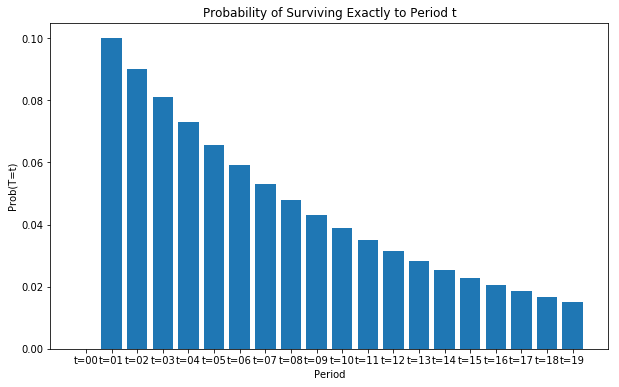

In [66]:
make_plot(p_t, "Probability of Surviving Exactly to Period t", "Period", "Prob(T=t)")

### Graph of Prob(T<=t) (Cumulative)

This is the probability that an entity survives all the periods up to and including $t$.

For example, the probabilty of surviving to the first, or to the second period, or to the third period is $0.1 + 0.09 + 0.081 = 0.271$.

| t | 1   | 2   | 3   | P(T=t) |
|---|-----|-----|-----|--------|
| 1 | 0.1 |     |     | 0.1    |
| 2 | 0.9 | 0.1 |     | 0.09   |
| 3 | 0.9 | 0.9 | 0.1 | 0.081  |

In [91]:
cumu_p_t = pd.Series(
    [
        sum(survive_exactly(death_chance, t)
        for t in range(0,i+1)) #range(0, 0) creates an empty list
        for i in range(0, n_periods)
    ],
    name="Prob(T<=t)",
    index=(f"t={t:02}" for t in range(0, n_periods))
    )
cumu_p_t

t=00    0.000000
t=01    0.100000
t=02    0.190000
t=03    0.271000
t=04    0.343900
t=05    0.409510
t=06    0.468559
t=07    0.521703
t=08    0.569533
t=09    0.612580
t=10    0.651322
t=11    0.686189
t=12    0.717570
t=13    0.745813
t=14    0.771232
t=15    0.794109
t=16    0.814698
t=17    0.833228
t=18    0.849905
t=19    0.864915
Name: Prob(T<=t), dtype: float64

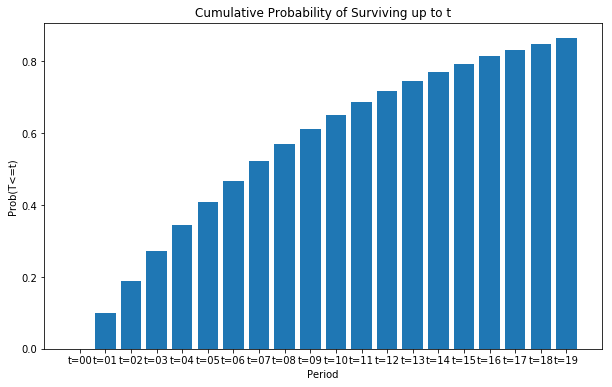

In [92]:
make_plot(cumu_p_t, "Cumulative Probability of Surviving up to t", "Period", "Prob(T<=t)")

### Graph of Prob(P>t) = 1 - Prob(P<=t) (Survival)

In [93]:
surv_p_t = 1 - cumu_p_t
surv_p_t

t=00    1.000000
t=01    0.900000
t=02    0.810000
t=03    0.729000
t=04    0.656100
t=05    0.590490
t=06    0.531441
t=07    0.478297
t=08    0.430467
t=09    0.387420
t=10    0.348678
t=11    0.313811
t=12    0.282430
t=13    0.254187
t=14    0.228768
t=15    0.205891
t=16    0.185302
t=17    0.166772
t=18    0.150095
t=19    0.135085
Name: Prob(T<=t), dtype: float64

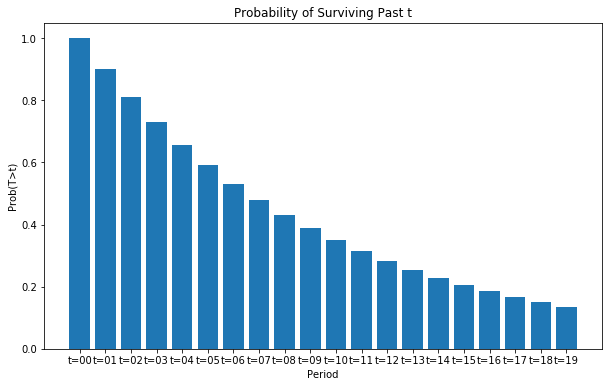

In [94]:
make_plot(surv_p_t, "Probability of Surviving Past t", "Period", "Prob(T>t)")